In [1]:
import json
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# LOAD DATA + COMPUTE PASS@K
RESULT_FILES = {
     "VSeek-EM": Path("../../results/vseek/VSeek-EM/mlvu/agent_results.jsonl"),
    "VSeek-Puls": Path("../../results/vseek/VSeek-Puls/mlvu/agent_results.jsonl"),
    "VSeek-Base": Path("../../results/vseek/Qwen3-VL-4B-Thinking/mlvu/agent_results.jsonl"),
    "Uniform": Path("../../results/uniform_vllm/mlvu/cot/f64/Qwen3-VL-4B-Thinking/agent_results.json"),
    "Vanilla RAG": Path("../../results/videorag_vllm/mlvu/cot/f64/Qwen3-VL-4B-Thinking/agent_results.json"),
}
datasets = ["mlvu", "lvb", "videomme"]



def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_json(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data)

def infer_total_passes(row: pd.Series) -> int:
    if "total_passes" in row and pd.notna(row["total_passes"]):
        return int(row["total_passes"])
    if "parsed_pred" in row and isinstance(row["parsed_pred"], list):
        return len(row["parsed_pred"])
    if "all_parsed_preds" in row and isinstance(row["all_parsed_preds"], list):
        return len(row["all_parsed_preds"])
    return 1


def pass_at_k_estimator(n: int, c: int, k: int) -> float:
    if n <= 0 or k <= 0:
        return 0.0
    if n < k:
        return 0.0
    if n - c < k:
        return 1.0
    return 1.0 - (math.comb(n - c, k) / math.comb(n, k))


def compute_pass_at_k(df: pd.DataFrame, ks: list[int]) -> pd.DataFrame:
    local_df = df.copy()
    local_df["n"] = local_df.apply(infer_total_passes, axis=1)
    local_df["c"] = local_df["correct_count"].fillna(0).astype(int)

    rows = []
    for k in ks:
        valid = local_df[local_df["n"] >= k]
        if len(valid) == 0:
            continue
        score = valid.apply(lambda r: pass_at_k_estimator(int(r["n"]), int(r["c"]), k), axis=1).mean()
        rows.append({"k": k, "pass_at_k": float(score), "num_samples": int(len(valid))})
    return pd.DataFrame(rows)

metrics_per_dataset = {}
for dataset in datasets:
    all_metrics = {}
    for name, path in RESULT_FILES.items():
        path = Path(str(path).replace("mlvu", dataset))
        if not path.exists():
            print(f"[skip] Missing file: {path}")
            continue
        if '.jsonl' in str(path):
            df = load_jsonl(path)
        else:
            df = load_json(path)
        if "correct_count" not in df.columns:
            print(f"[skip] Missing 'correct_count' in {path}")
            continue

        max_n = int(df.apply(infer_total_passes, axis=1).max()) if len(df) else 0
        default_ks = [1, 2, 4, 5, 8, 10, 16]
        ks = sorted(set([k for k in default_ks if k <= max_n] + ([max_n] if max_n > 0 else [])))

        metrics_df = compute_pass_at_k(df, ks)
        all_metrics[name] = metrics_df

        print(f"\n{name} {dataset}")
        display(metrics_df)
    metrics_per_dataset[dataset] = all_metrics


VSeek-EM mlvu


,k,pass_at_k,num_samples
0,1,0.643917,2174
1,2,0.721677,2174
2,4,0.780075,2174
3,5,0.795555,2174
4,8,0.823400,2174
5,10,0.834610,2174
6,16,0.855106,2174



VSeek-Puls mlvu


,k,pass_at_k,num_samples
0,1,0.662201,2174
1,2,0.733184,2174
2,4,0.782803,2174
3,5,0.795989,2174
4,8,0.821113,2174
5,10,0.831960,2174
6,16,0.852806,2174



VSeek-Base mlvu


...

,k,pass_at_k,num_samples
0,1,0.493194,2700
1,2,0.601907,2700
2,4,0.692479,2700
3,5,0.717660,2700
4,8,0.764516,2700
5,10,0.783877,2700
6,16,0.818519,2700



Uniform videomme


,k,pass_at_k,num_samples
0,1,0.584583,2700
1,2,0.621969,2700
2,4,0.653980,2700
3,5,0.663166,2700
4,8,0.680826,2700
5,10,0.688556,2700
6,16,0.704074,2700



Vanilla RAG videomme


,k,pass_at_k,num_samples
0,1,0.548333,2700
1,2,0.592025,2700
2,4,0.628619,2700
3,5,0.639100,2700
4,8,0.659448,2700
5,10,0.668410,2700
6,16,0.685926,2700


mlvu


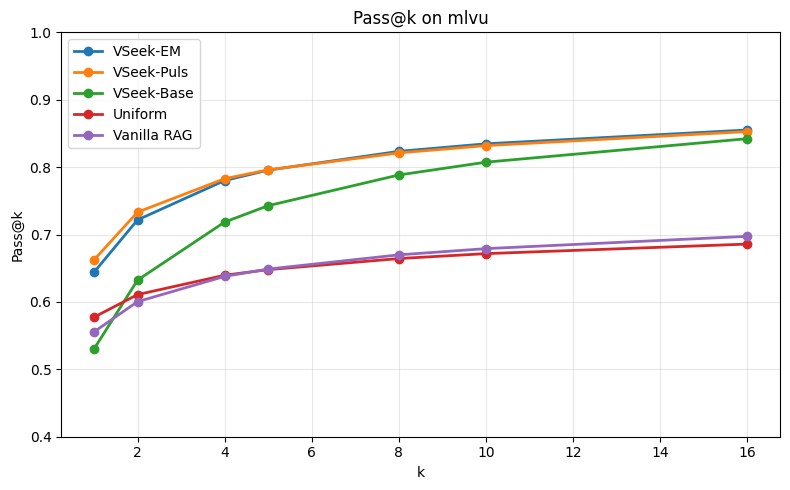

lvb


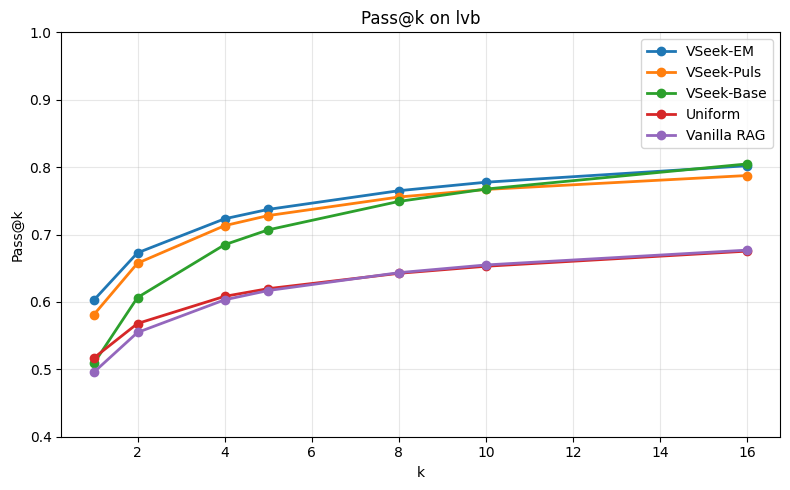

videomme


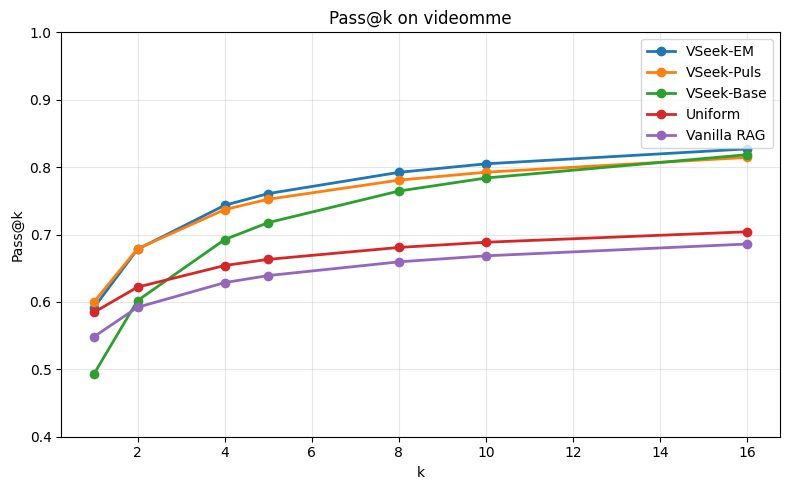

In [3]:
# PLOT DATA
for dataset, all_metrics in metrics_per_dataset.items():
    print(dataset)
    plt.figure(figsize=(8, 5))

    for name, metrics_df in all_metrics.items():
        if metrics_df.empty:
            continue
        plt.plot(metrics_df["k"], metrics_df["pass_at_k"], marker="o", linewidth=2, label=name)

    plt.title(f"Pass@k on {dataset}")
    plt.xlabel("k")
    plt.ylabel("Pass@k")
    plt.ylim(0.4, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()